# 03 - Walker Constellation

This notebook shows the current NSTK Walker workflow:

1. call `nstk.initialize(offline=True)` once
2. build a seed propagator with a factory function
3. use module-level Walker builders
4. work with the resulting `Orbit` objects directly


In [1]:
# Ensure local package import when running from this examples/ folder.
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
_repo_root = _cwd if (_cwd / "nstk").is_dir() else _cwd.parent
if (_repo_root / "nstk").is_dir() and str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
%matplotlib widget


In [2]:
import nstk
import numpy as np
from astropy.time import Time

nstk.initialize(offline=True)

from nstk.plotting import plot_orbits
from nstk.propagation import (
    Orbit,
    TwoBodyPropagatorFactory,
    build_two_body_propagator,
    build_two_body_walker_constellation,
    build_numerical_walker_constellation,
    build_walker_constellation,
    build_walker_initial_states,
)

np.set_printoptions(precision=6, suppress=True)


In [3]:
# 1) Build a seed orbit by constructing a propagator, then wrapping it with Orbit.
epoch = Time("2026-01-01T00:00:00", scale="utc")

seed = Orbit(
    build_two_body_propagator(
        epoch=epoch,
        a=7000e3,
        e=0.001,
        i=np.deg2rad(53.0),
        raan=np.deg2rad(20.0),
        argp=np.deg2rad(15.0),
        anomaly=np.deg2rad(10.0),
        anomaly_type="mean",
        inertial_frame="gcrf",
    )
)

print("seed epoch:", seed.epoch.isot)
print("seed native frame:", seed.native_frame.getName())
print("seed provider:", seed.get_attitude_provider().getClass().getSimpleName())


seed epoch: 2026-01-01T00:00:00.000
seed native frame: GCRF
seed provider: LofOffset


full-span count: 24
sat0 |r| [km], |v| [m/s]: 6993.106557116952 7553.488136651924
sat1 |r| [km], |v| [m/s]: 7001.2223243955395 7544.735730128401


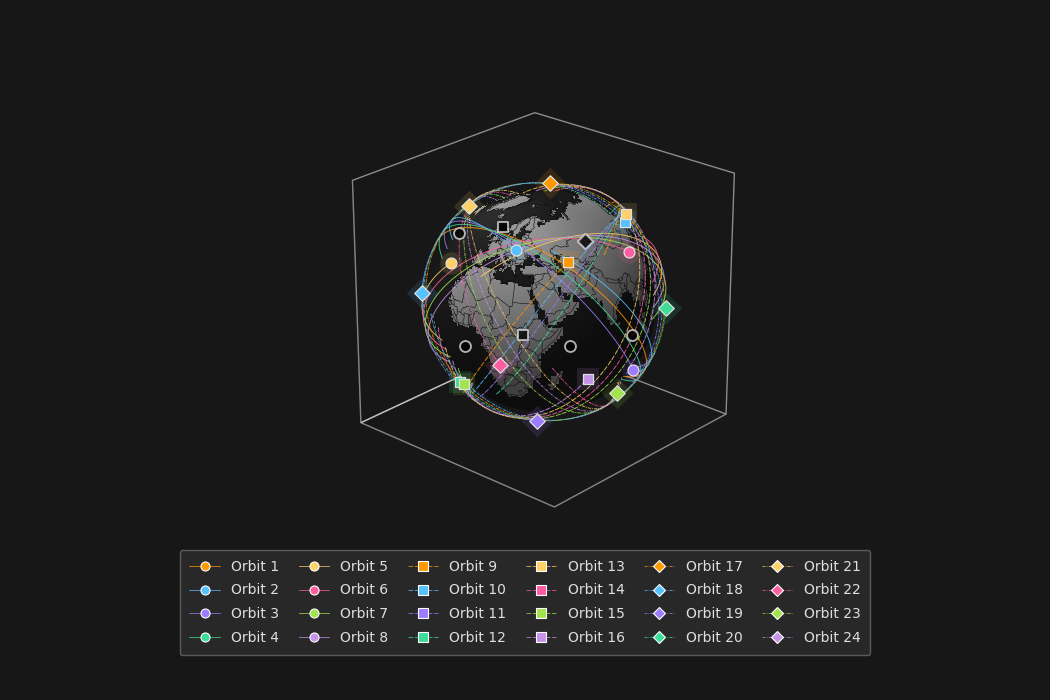

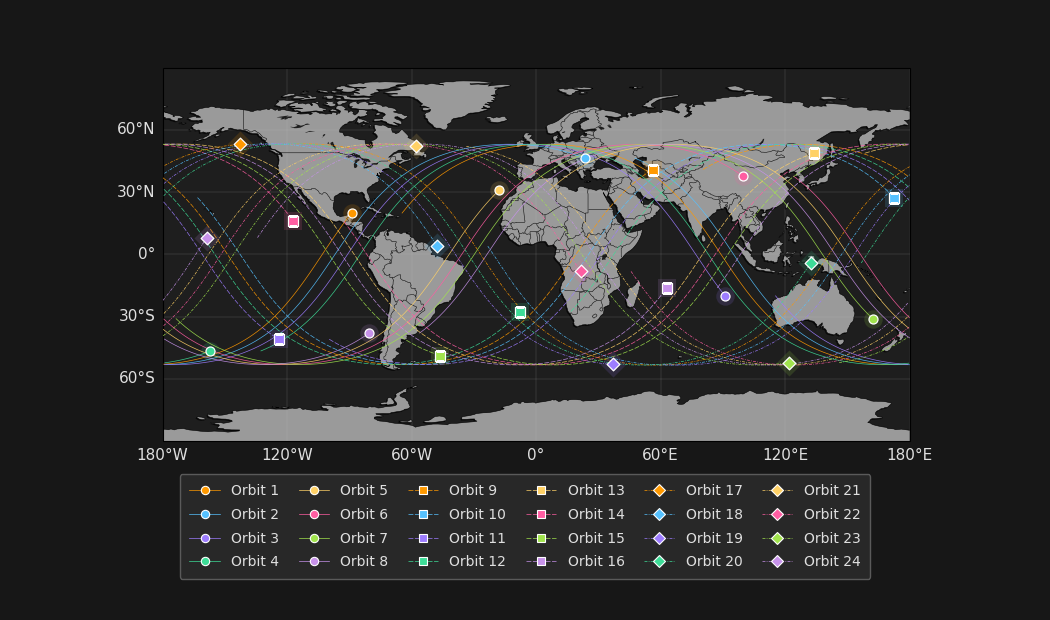

(<Figure size 1050x620 with 1 Axes>, <GeoAxes: >)

In [4]:
# 2) Full-span Walker: T/P/F = 24/6/1
full_span = build_two_body_walker_constellation(
    epoch=epoch,
    a=7000e3,
    e=0.001,
    i=np.deg2rad(53.0),
    raan=np.deg2rad(20.0),
    argp=np.deg2rad(15.0),
    anomaly=np.deg2rad(10.0),
    anomaly_type="mean",
    inertial_frame="gcrf",
    total_satellites=24,
    num_planes=6,
    include_seed=True,
)

print("full-span count:", len(full_span))
r0, v0 = full_span[0].get_pv(0.0, frame="native")
r1, v1 = full_span[1].get_pv(0.0, frame="native")
print("sat0 |r| [km], |v| [m/s]:", np.linalg.norm(r0) / 1e3, np.linalg.norm(v0))
print("sat1 |r| [km], |v| [m/s]:", np.linalg.norm(r1) / 1e3, np.linalg.norm(v1))
plot_orbits(full_span, view="3d", line_width=0.5)
plot_orbits(full_span, view="2d", line_width=0.5)


half-span count: 23
last half-span sat |r| [km], |v| [m/s]: 6998.491596942224 7547.679535322646


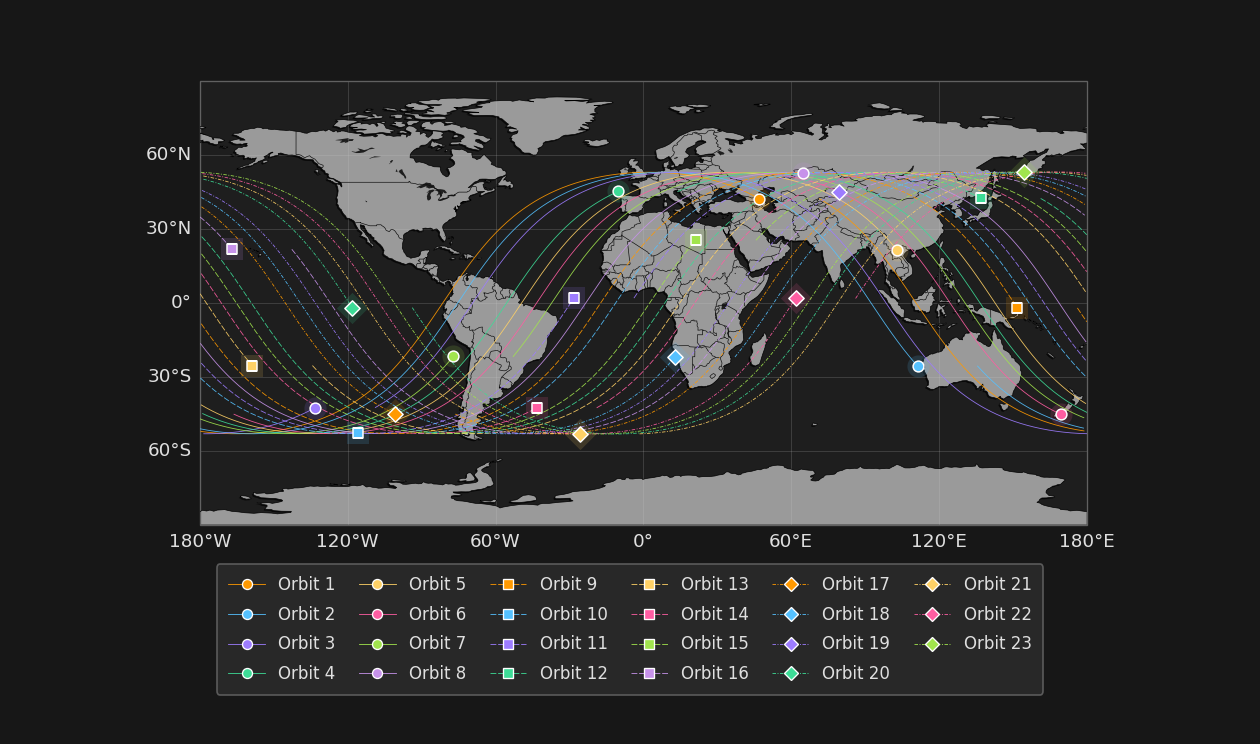

(<Figure size 1260x744 with 1 Axes>, <GeoAxes: >)

In [5]:
# 3) Custom half-span Walker with explicit offsets
half_span = build_two_body_walker_constellation(
    epoch=epoch,
    a=7000e3,
    e=0.001,
    i=np.deg2rad(53.0),
    raan=np.deg2rad(20.0),
    argp=np.deg2rad(15.0),
    anomaly=np.deg2rad(10.0),
    anomaly_type="mean",
    inertial_frame="gcrf",
    total_satellites=24,
    num_planes=6,
    phasing=2,
    raan_span=np.pi,
    initial_raan_offset=np.deg2rad(15.0),
    initial_anomaly_offset=np.deg2rad(7.5),
    include_seed=False,
)

print("half-span count:", len(half_span))
r_last, v_last = half_span[-1].get_pv(0.0, frame="native")
print("last half-span sat |r| [km], |v| [m/s]:", np.linalg.norm(r_last) / 1e3, np.linalg.norm(v_last))
plot_orbits(half_span, view="2d", line_width=0.5)


numerical walker count: 12
first propagator class: NumericalPropagator
first force-model count: 2


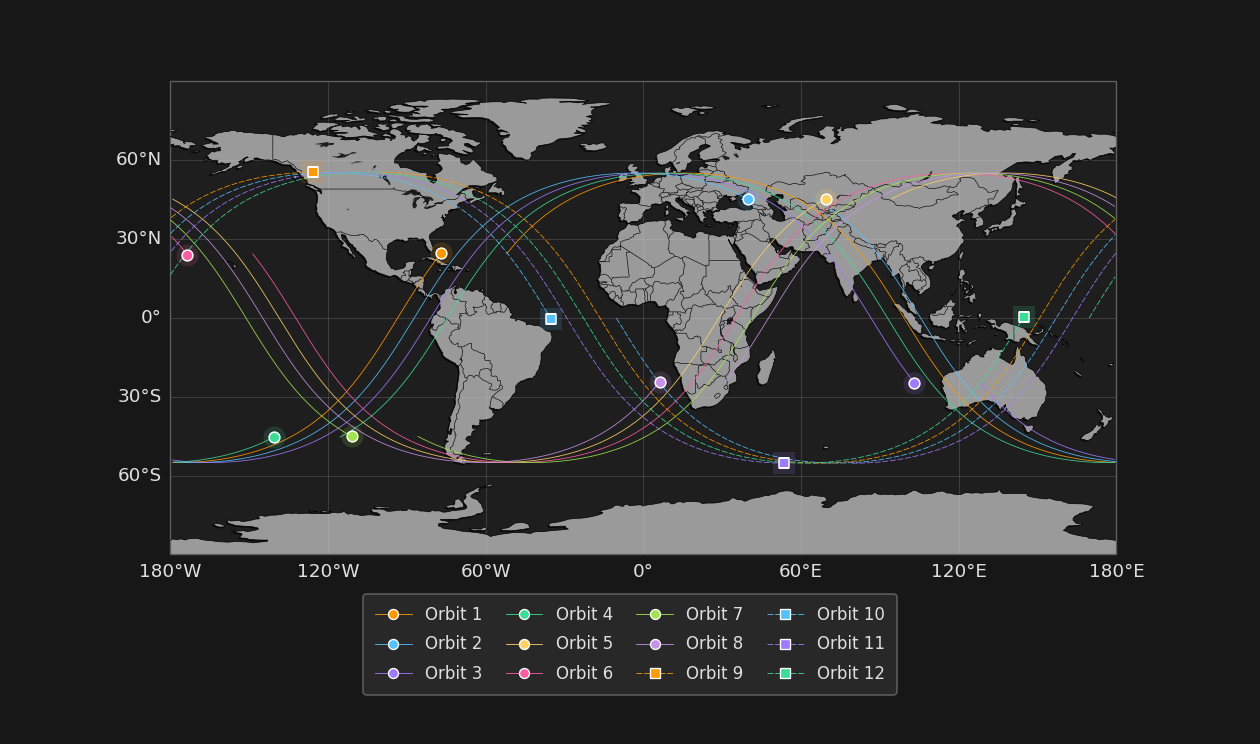

(<Figure size 1260x744 with 1 Axes>, <GeoAxes: >)

In [6]:
# 4) Numerical Walker from the built-in numerical factory path
walker_num = build_numerical_walker_constellation(
    epoch=epoch,
    a=7100e3,
    e=0.002,
    i=np.deg2rad(55.0),
    raan=np.deg2rad(30.0),
    argp=np.deg2rad(25.0),
    anomaly=np.deg2rad(5.0),
    anomaly_type="mean",
    inertial_frame="gcrf",
    gravity_degree=8,
    gravity_order=8,
    enable_drag=False,
    enable_third_body=False,
    enable_srp=False,
    total_satellites=12,
    num_planes=3,
    phasing=1,
    include_seed=True,
)

print("numerical walker count:", len(walker_num))
print("first propagator class:", walker_num[0].propagator.getClass().getSimpleName())
print("first force-model count:", walker_num[0].propagator.getAllForceModels().size())
plot_orbits(walker_num, view="2d", line_width=0.5)


walkerized state count: 6
custom walker count: 6
first custom walker provider: LofOffset


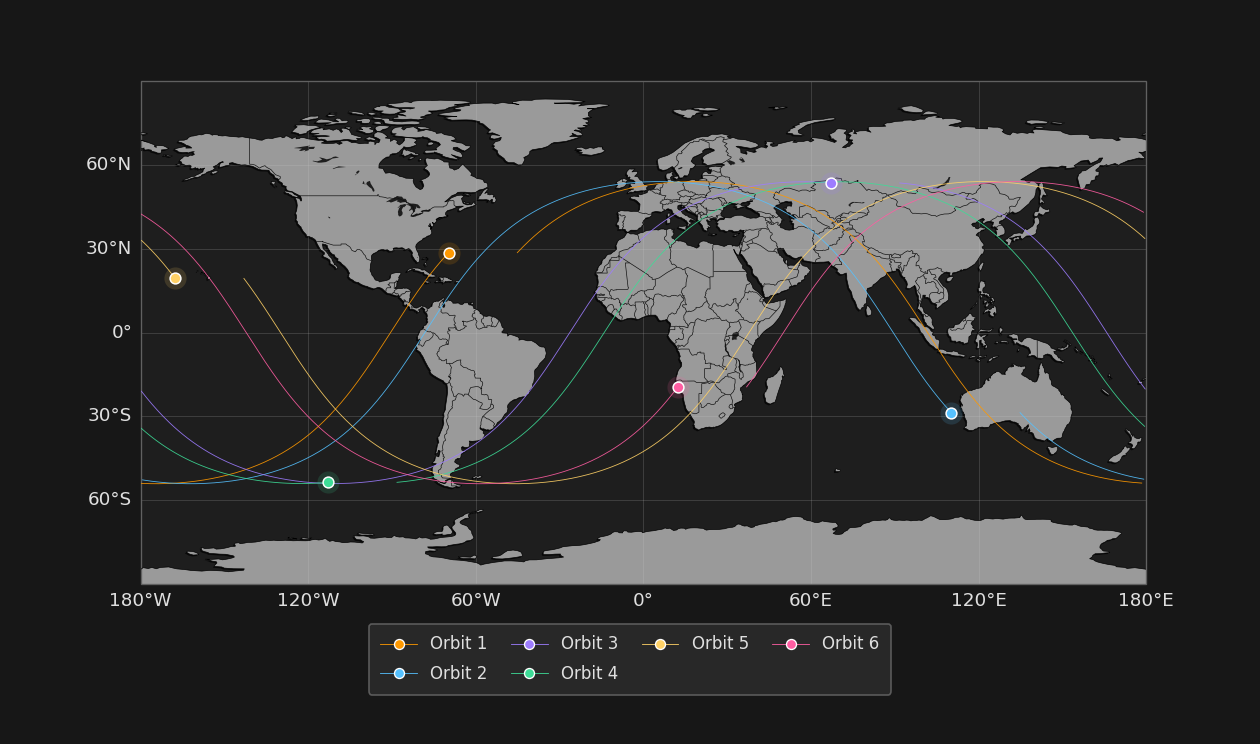

(<Figure size 1260x744 with 1 Axes>, <GeoAxes: >)

In [7]:
# 5) Advanced path: generate Walkerized states, then supply your own propagator factory
seed_custom = Orbit(
    build_two_body_propagator(
        epoch=epoch,
        a=7050e3,
        e=0.0015,
        i=np.deg2rad(54.0),
        raan=np.deg2rad(12.0),
        argp=np.deg2rad(18.0),
        anomaly=np.deg2rad(6.0),
        anomaly_type="mean",
        inertial_frame="gcrf",
        mass=275.0,
    )
)

walker_states = build_walker_initial_states(
    seed_custom,
    total_satellites=6,
    num_planes=3,
    phasing=1,
    raan_span=np.pi,
    initial_raan_offset=np.deg2rad(20.0),
    initial_anomaly_offset=np.deg2rad(12.0),
    anomaly_type="true",
    include_seed=True,
)

custom_walker = build_walker_constellation(
    seed_custom,
    total_satellites=6,
    num_planes=3,
    phasing=1,
    raan_span=np.pi,
    initial_raan_offset=np.deg2rad(20.0),
    initial_anomaly_offset=np.deg2rad(12.0),
    anomaly_type="true",
    include_seed=True,
    propagator_factory=TwoBodyPropagatorFactory(
        attitude_provider=seed_custom.get_attitude_provider(),
    ),
)

print("walkerized state count:", len(walker_states))
print("custom walker count:", len(custom_walker))
print("first custom walker provider:", custom_walker[0].get_attitude_provider().getClass().getSimpleName())
plot_orbits(custom_walker, view="2d", line_width=0.5)


Next notebook: **04 - Coverage**.
